# Final Project

In [34]:
import pandas as pd
import numpy as np

# Base Model

/var/folders/q5/4dwv3_jj3f7bdc6jpw6sl7dr0000gn/T/ipykernel_10611/3911747128.py:2: DtypeWarning: Columns (2,4,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_artists = pd.read_csv('artists.csv')


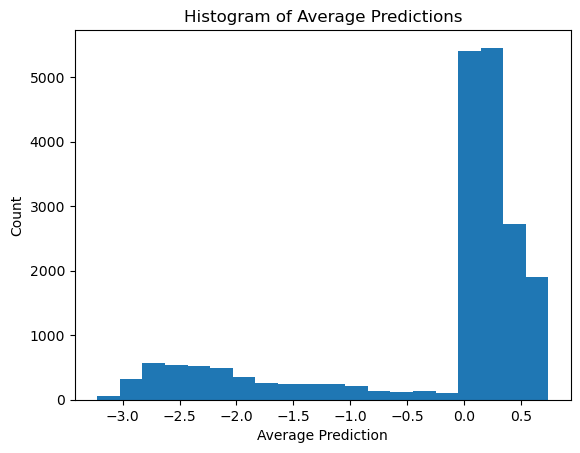

In [35]:
#load up the artists dataset
df_artists = pd.read_csv('artists.csv')
#load up the songs_with_predictions_small.csv datasset
df_songs = pd.read_csv('songs_with_predictions_small.csv')

df_songs.sort_values(by='average_prediction', ascending=False, inplace=True)

# plot a histogram of the average predictions
import matplotlib.pyplot as plt
plt.hist(df_songs['average_prediction'], bins=20)
plt.xlabel('Average Prediction')
plt.ylabel('Count')
plt.title('Histogram of Average Predictions')
plt.show()

In [36]:
from gurobipy import Model, GRB, quicksum
songs_dict =df_songs.to_dict(orient="list")


target_user = "user_5c0cba28e67a99c235ef2ba9877fef44"
ratings = songs_dict[target_user]
ratings

track_names = songs_dict['track_name']
num_tracks = len(track_names)

artists = songs_dict['artist_name']
unique_artists = list(set(artists))

In [37]:
m = Model("music_recommendation_with_artist_diversity")

# binary variable for every song whether is in the playlist or not
z = m.addVars(num_tracks, vtype=GRB.BINARY, name="z")
# binary variable for every artist whether is in the playlist or not
x = m.addVars(unique_artists, vtype=GRB.BINARY, name="x")

# sum of z is 20
m.addConstr(quicksum(z[i] for i in range(num_tracks)) == 20, "num_tracks")

for artist in unique_artists:
    m.addConstr(x[artist] <= quicksum(z[i] for i in range(num_tracks) if artists[i] == artist), "artist_{}".format(artist))

def get_playlist(w, m):
    # objective function
    # x * the highest rated tracks for the target_user + 1-w * the number of unique artists
    m.setObjective(w * quicksum(ratings[i] * z[i] for i in range(num_tracks)) + (1 - w) * quicksum(x[artist] for artist in unique_artists), GRB.MAXIMIZE)

    # optimize the model
    m.optimize()

    selected_track_indx = [i for i in range(num_tracks) if z[i].x > 0.5]
    total_ratings = sum(ratings[i] for i in selected_track_indx)
    num_artists = len(set(artists[i] for i in selected_track_indx))
    return total_ratings, num_artists, selected_track_indx

In [38]:
total_ratings, num_artists, selected_track_index = get_playlist(0.5, m)
# print out the selected tracks in a table
selected_tracks = []
for i in selected_track_index:
    selected_tracks.append((track_names[i], artists[i], ratings[i]))
df_selected_tracks = pd.DataFrame(selected_tracks, columns=["track_name", "artist_name", "rating"])
df_selected_tracks.sort_values(by='rating', ascending=False, inplace=True)
df_selected_tracks.reset_index(drop=True, inplace=True)
df_selected_tracks.head(20)

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[arm] - Darwin 24.4.0 24E263)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 7481 rows, 27480 columns and 47480 nonzeros
Model fingerprint: 0x54b79999
Variable types: 0 continuous, 27480 integer (27480 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e-04, 2e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e+01, 2e+01]
Found heuristic solution: objective 9.2970976
Presolve removed 6082 rows and 22340 columns
Presolve time: 0.05s
Presolved: 1399 rows, 5140 columns, 8403 nonzeros
Found heuristic solution: objective 10.3103042
Variable types: 0 continuous, 5140 integer (4744 binary)

Root relaxation: objective 1.938704e+01, 460 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node T

,track_name,artist_name,rating
0,Lovers In Japan (Acoustic Version),Coldplay,1.329584
1,Dj Skylat Dope Mix ft.Jamiroquai,Daft Punk,1.245485
2,What's My Name (Kik Klap Extended Mix),Rihanna,1.238411
3,The Glory - Album Version (Edited),Kanye West,1.181904
4,It's your life (feat. Chris Willis),David Guetta,1.138525
5,Work It Out - New Radio Edit,Beyoncé,1.131092
6,3 a.m. (Produced By Dr. Dre),Eminem,1.101457
7,Out Of Goodbyes With Lady Antebellum,Maroon 5,1.079023
8,Judas - DJ White Shadow Remix,Lady Gaga,0.964962
9,Dark Horse (feat. TEE),Katy Perry,0.932020


# Building on the Base Model

We found 2 Spotify datasets on Kaggle, 'dataset.csv' and 'spotify_songs.csv', to incorporate more attributes to each song.
We attempted to merge the datasets with the 'songs_with_predictions_small.csv' from class utilizing track_name. 

In [39]:
# I need to merge dataset.csv and songs_with_predictions_small.csv on track_name
# and then save the merged dataset to a new CSV file called merged_dataset.csv
# The merged dataset should contain all columns from both datasets
# and should be saved in the same directory as the script

# Read the datasets
dataset = pd.read_csv('dataset.csv')
songs_with_predictions = pd.read_csv('songs_with_predictions_small.csv')
# Merge the datasets on track_name
merged_dataset = pd.merge(dataset, songs_with_predictions, on='track_name', how='inner')
# Remove duplicate rows on track_id
merged_dataset = merged_dataset.drop_duplicates(subset=['track_id'])


# Save the merged dataset to a new CSV file
merged_dataset.to_csv('merged_dataset.csv', index=False)
# Print the first few rows of the merged dataset
print(merged_dataset.head())
# Print the length of the merged dataset
print(len(merged_dataset))


   Unnamed: 0                track_id                    artists  \
0           3  6lfxq3CG4xtTiEg7opyCyx               Kina Grannis   
1           4  5vjLSffimiIP26QG5WcN2K           Chord Overstreet   
4           8  0IktbUcnAGrvD03AWnz3Q8  Jason Mraz;Colbie Caillat   
6          18  2qLMf6TuEC3ruGJg4SMMN6  Jason Mraz;Colbie Caillat   
8          26  5IfCZDRXZrqZSm8AwE44PG                 Jason Mraz   

                                          album_name  \
0  Crazy Rich Asians (Original Motion Picture Sou...   
1                                            Hold On   
4                We Sing. We Dance. We Steal Things.   
6                We Sing. We Dance. We Steal Things.   
8                              Holly Jolly Christmas   

                   track_name  popularity  duration_ms  explicit  \
0  Can't Help Falling In Love          71       201933     False   
1                     Hold On          82       198853     False   
4                       Lucky          74       18

In [40]:
# I need to merge spotify_songs.csv and songs_with_predictions_small.csv on track_name
# and then save the merged dataset to a new CSV file called merged_dataset.csv
# The merged dataset should contain all columns from both datasets
# and should be saved in the same directory as the script

# Read the datasets
spotify_songs = pd.read_csv('spotify_songs.csv')
# Merge the datasets on track_name
merged_dataset = pd.merge(spotify_songs, songs_with_predictions, on='track_name', how='inner')
# Remove duplicate rows on track_id
merged_dataset = merged_dataset.drop_duplicates(subset=['track_id'])
# Save the merged dataset to a new CSV file
merged_dataset.to_csv('merged_dataset2.csv', index=False)
# Print the first few rows of the merged dataset
print(merged_dataset.head())
# Print the length of the merged dataset
print(len(merged_dataset))

                 track_id     track_name      track_artist  track_popularity  \
0  05CwHjIk71RXVU40boRMnR  Call You Mine  The Chainsmokers                39   
1  6nDKrPlXdpomGBgAlO7UdP            SOS            Avicii                30   
3  1LjxmkW3xRQP2HzswhYyyc   Let It Be Me        Steve Aoki                52   
4  6QcrReLyoun4xrPVsZ5OJE            Lie           Shallou                41   
5  6uBhi9gBXWjanegOb2Phh0           Stay              Zedd                79   

           track_album_id track_album_name track_album_release_date  \
0  1ONuDpN0a3zhCUyKCgtuzK    World War Joy               2019-05-31   
1  7Jx7doYIXITyR2LQB0Hvbc              SOS               2019-04-10   
3  6nPJEALAjWKOE1jWPws7jj     Let It Be Me               2019-09-06   
4  4v1f4kZMvCpwCSwkxC82ia              Lie               2018-01-25   
5  1I4W7JKzYbl8VKRfD61DIS             Stay               2017-02-23   

  playlist_name             playlist_id playlist_genre  ...  \
0     Dance Pop  37i9dQZF1DWZ

The 'dataset.csv' merge has more songs in common so we will utilize this file for our project.

# Spotify Daylist Playlist

Enter a user and time of day (or utilize the current time) to create a personalized playlist.

We will create a playlist for the current time of day. If you want to set your own time, comment out this code.

In [41]:
# Get the time of day
from datetime import datetime
now = datetime.now()
current_time = now.strftime("%H:%M:%S")
print("Current Time =", current_time)

Current Time = 17:20:45


If you want to set your own time, uncomment this code and enter the time in 'time' in the format of '1pm' or '9am'.

In [ ]:
# ## EDIT HERE
# time = '1am'

# # Convert time to datetime object
# from datetime import datetime
# time_obj = datetime.strptime(time, '%I%p')
# current_time = time_obj.strftime("%H:%M:%S")
# print("Current Time =", current_time)

Current Time = 01:00:00
